In [6]:
import pandas as pd
import numpy as np
import os

# 🔹 Step 1: Create folder if not exists
os.makedirs("data", exist_ok=True)

# 🔹 Step 2: Generate date range (fixed warning using 'ME')
dates = pd.date_range(start="2000-01-01", periods=300, freq='ME')

# 🔹 Step 3: Generate realistic temperature data
np.random.seed(42)  # for reproducibility
temp = 20 + np.sin(np.arange(300)/12)*2 + np.random.randn(300)

# 🔹 Step 4: Create DataFrame
df = pd.DataFrame({
    "Date": dates,
    "Temperature": temp
})

# 🔹 Step 5: Save CSV
df.to_csv("data/climate.csv", index=False)

# 🔹 Step 6: Confirmation
print("✅ climate.csv file created successfully in 'data' folder!")
print(df.head())

✅ climate.csv file created successfully in 'data' folder!
        Date  Temperature
0 2000-01-31    20.496714
1 2000-02-29    20.028210
2 2000-03-31    20.979481
3 2000-04-30    22.017838
4 2000-05-31    20.420236


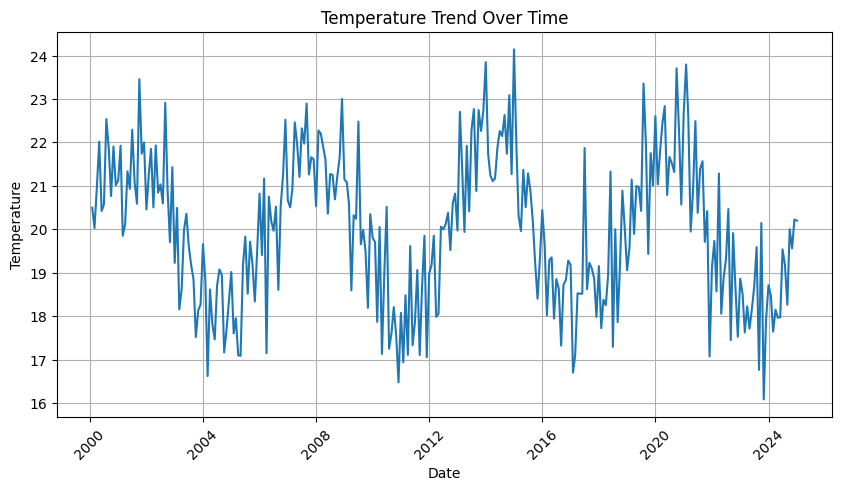

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Temperature'])
plt.title("Temperature Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.xticks(rotation=45)
plt.grid()

plt.savefig("outputs_trend.png")
plt.show()

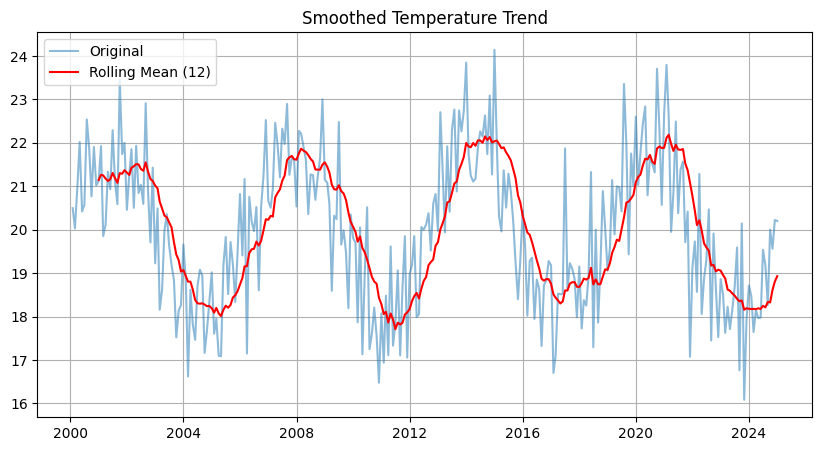

In [8]:
df['Date'] = pd.to_datetime(df['Date'])

df['Rolling_Mean'] = df['Temperature'].rolling(window=12).mean()

plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Temperature'], label='Original', alpha=0.5)
plt.plot(df['Date'], df['Rolling_Mean'], label='Rolling Mean (12)', color='red')

plt.title("Smoothed Temperature Trend")
plt.legend()
plt.grid()

plt.savefig("rolling_mean.png")
plt.show()

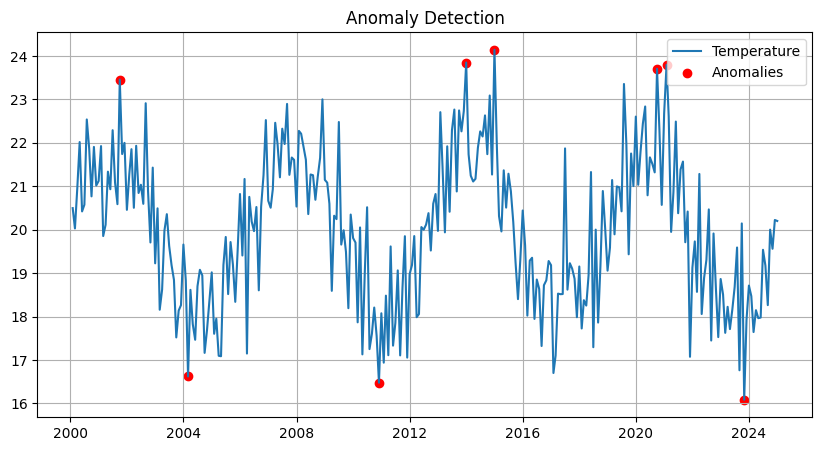

In [9]:
import numpy as np

mean = df['Temperature'].mean()
std = df['Temperature'].std()

df['Anomaly'] = abs(df['Temperature'] - mean) > 2 * std

# Plot anomalies
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Temperature'], label='Temperature')

plt.scatter(df[df['Anomaly']]['Date'],
            df[df['Anomaly']]['Temperature'],
            color='red', label='Anomalies')

plt.title("Anomaly Detection")
plt.legend()
plt.grid()

plt.savefig("anomalies.png")
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

df['Year'] = pd.to_datetime(df['Date']).dt.year

X = df[['Year']]
y = df['Temperature']

model = LinearRegression()
model.fit(X, y)

future_years = np.arange(2025, 2035).reshape(-1,1)
predictions = model.predict(future_years)

print("Future Predictions:")
for year, temp in zip(range(2025,2035), predictions):
    print(f"{year}: {temp:.2f}")

In [10]:
from sklearn.linear_model import LinearRegression
import numpy as np

df['Year'] = pd.to_datetime(df['Date']).dt.year

X = df[['Year']]
y = df['Temperature']

model = LinearRegression()
model.fit(X, y)

future_years = np.arange(2025, 2035).reshape(-1,1)
predictions = model.predict(future_years)

print("Future Predictions:")
for year, temp in zip(range(2025,2035), predictions):
    print(f"{year}: {temp:.2f}")

Future Predictions:
2025: 19.60
2026: 19.57
2027: 19.54
2028: 19.50
2029: 19.47
2030: 19.44
2031: 19.41
2032: 19.38
2033: 19.35
2034: 19.32


c:\Users\anees\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
import matplotlib.pyplot as plt
import os

def plot_trend(df):
    # ✅ Create folder automatically
    if not os.path.exists("outputs/graphs"):
        os.makedirs("outputs/graphs")

    plt.figure(figsize=(10,5))
    plt.plot(df['Date'], df['Temperature'])

    plt.title("Temperature Trend")
    plt.xlabel("Date")
    plt.ylabel("Temperature")

    plt.savefig("outputs/graphs/temp_trend.png")
    plt.show()

    print("✅ Trend graph saved")